# Integration Planning at SFB — RCC Departure Prediction Model

**Objective:** Build a logistic regression model to predict which employees will voluntarily leave (accept the RCC) and apply it to Lyon branch employees.

**Data:**
- `employee_attrition_dataset.csv` — historical data from past RCC offers (training)
- `employee_attrition_predictions_to_be_given.csv` — Lyon employees (for predictions)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14

## 1. Load & Explore Training Data

In [2]:
df = pd.read_csv('employee_attrition_dataset.csv')
lyon = pd.read_csv('employee_attrition_predictions_to_be_given.csv')

print(f'Training data shape: {df.shape}')
print(f'Lyon data shape:     {lyon.shape}')
df.head()

Training data shape: (771, 36)
Lyon data shape:     (258, 35)


,SequenceNumber,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,59.0000,No,Travel_Rarely,818.0000,Human Resources,6.0000,2,Medical,1,321,2,Male,52,3,1,Human Resources,3,Married,2267,25657,8,Y,No,17,3,4,80,0,7,2,2,2,2,2,2
1,1,56.0000,No,Travel_Rarely,832.0000,Research & Development,9.0000,3,Medical,1,762,3,Male,81,3,4,Healthcare Representative,4,Married,11103,20420,7,Y,No,11,3,3,80,0,30,1,2,10,7,1,1
2,2,34.0000,No,Non-Travel,1381.0000,Sales,4.0000,4,Marketing,1,523,3,Female,72,3,2,Sales Executive,3,Married,6538,12740,9,Y,No,15,3,1,80,1,6,3,3,3,2,1,2
3,3,37.0000,No,Travel_Rarely,1107.0000,Research & Development,14.0000,3,Life Sciences,1,515,4,Female,95,3,1,Laboratory Technician,1,Divorced,3034,26914,1,Y,No,12,3,3,80,1,18,2,2,18,7,12,17
4,4,38.0000,No,Travel_Rarely,157.0000,Research & Development,1.0000,3,Medical,1,1952,3,Male,95,3,1,Laboratory Technician,1,Single,2867,20006,0,Y,No,13,3,4,80,0,8,6,2,7,7,7,6


Target distribution:
Attrition
No     628
Yes    143
Name: count, dtype: int64

Leave rate: 18.5%


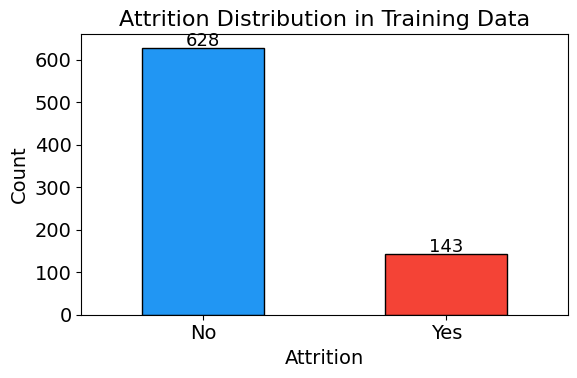

In [3]:
# Target distribution
attrition_counts = df['Attrition'].value_counts()
print('Target distribution:')
print(attrition_counts)
print(f'\nLeave rate: {attrition_counts["Yes"] / len(df):.1%}')

fig, ax = plt.subplots(figsize=(6, 4))
attrition_counts.plot(kind='bar', ax=ax, color=['#2196F3', '#F44336'], edgecolor='black')
ax.set_title('Attrition Distribution in Training Data', fontsize=16)
ax.set_xlabel('Attrition', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# Summary statistics for key numeric variables
numeric_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance',
                'EnvironmentSatisfaction', 'JobInvolvement']
df[numeric_cols + ['Attrition']].groupby('Attrition').mean().T

Attrition,No,Yes
Age,38.3551,34.4895
MonthlyIncome,6575.5398,4339.9790
TotalWorkingYears,11.6401,7.3566
YearsAtCompany,7.5287,4.6993
DistanceFromHome,9.7420,11.4406
JobSatisfaction,2.7675,2.5035
WorkLifeBalance,2.7564,2.6923
EnvironmentSatisfaction,2.7197,2.5524
JobInvolvement,2.7452,2.5175


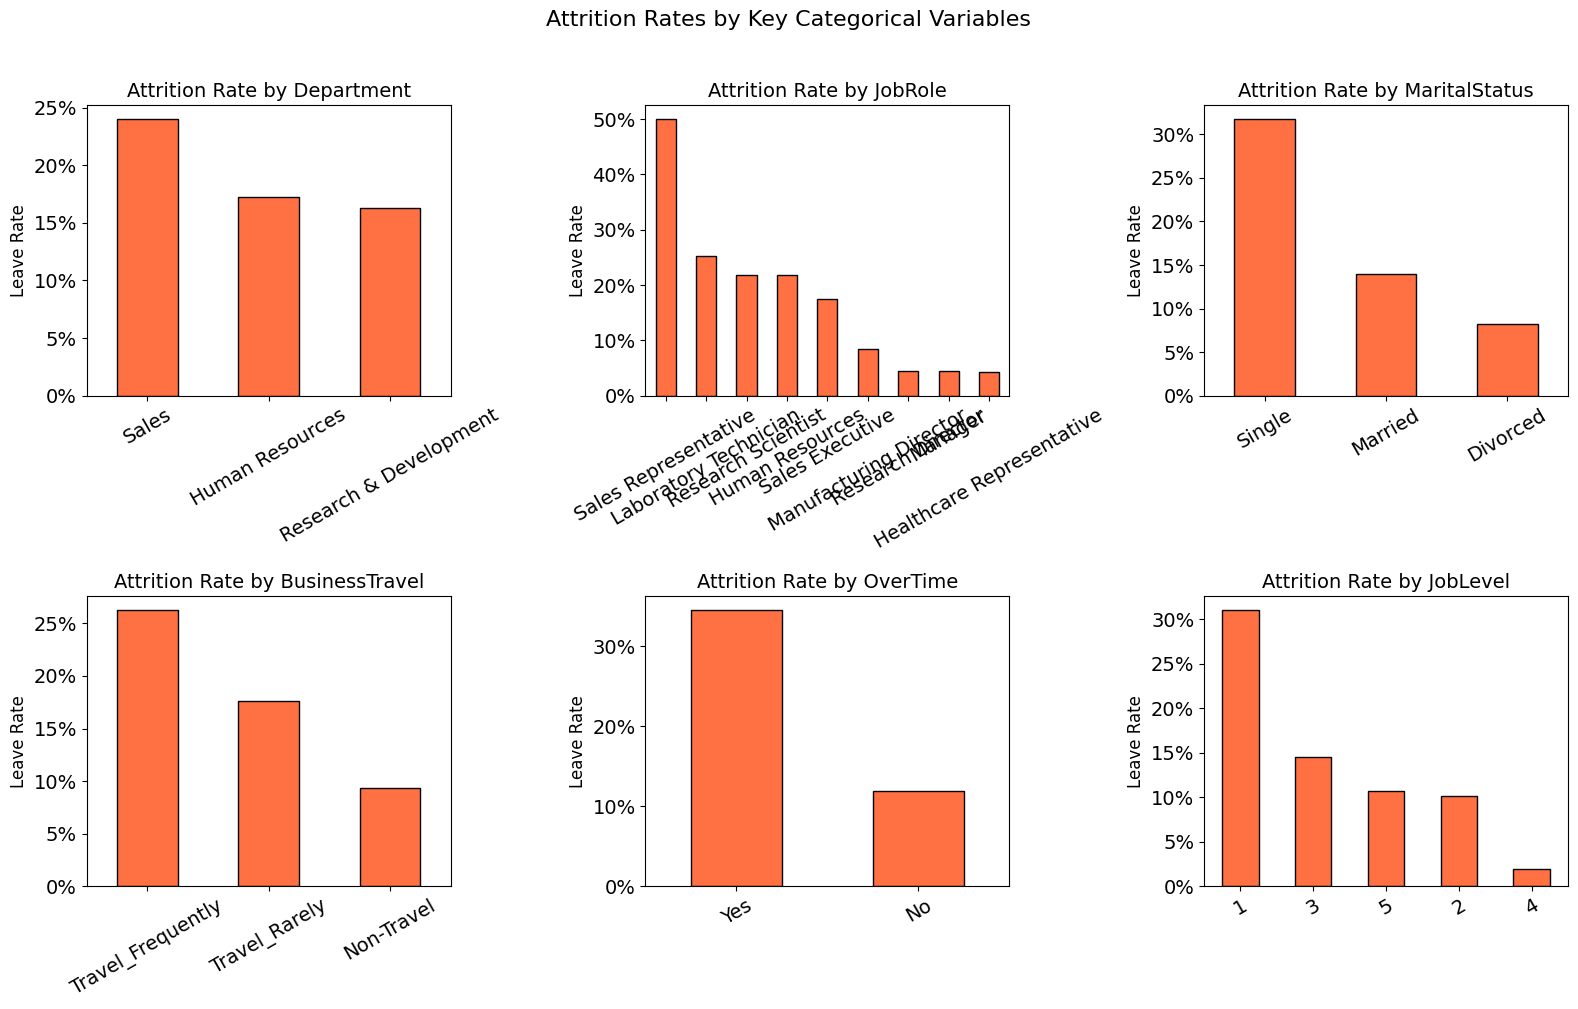

In [5]:
# Key factor analysis: Attrition rates by categorical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cat_vars = ['Department', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'OverTime', 'JobLevel']

for ax, var in zip(axes.flatten(), cat_vars):
    rates = df.groupby(var)['Attrition'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#FF7043', edgecolor='black')
    ax.set_title(f'Attrition Rate by {var}', fontsize=14)
    ax.set_ylabel('Leave Rate', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Attrition Rates by Key Categorical Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

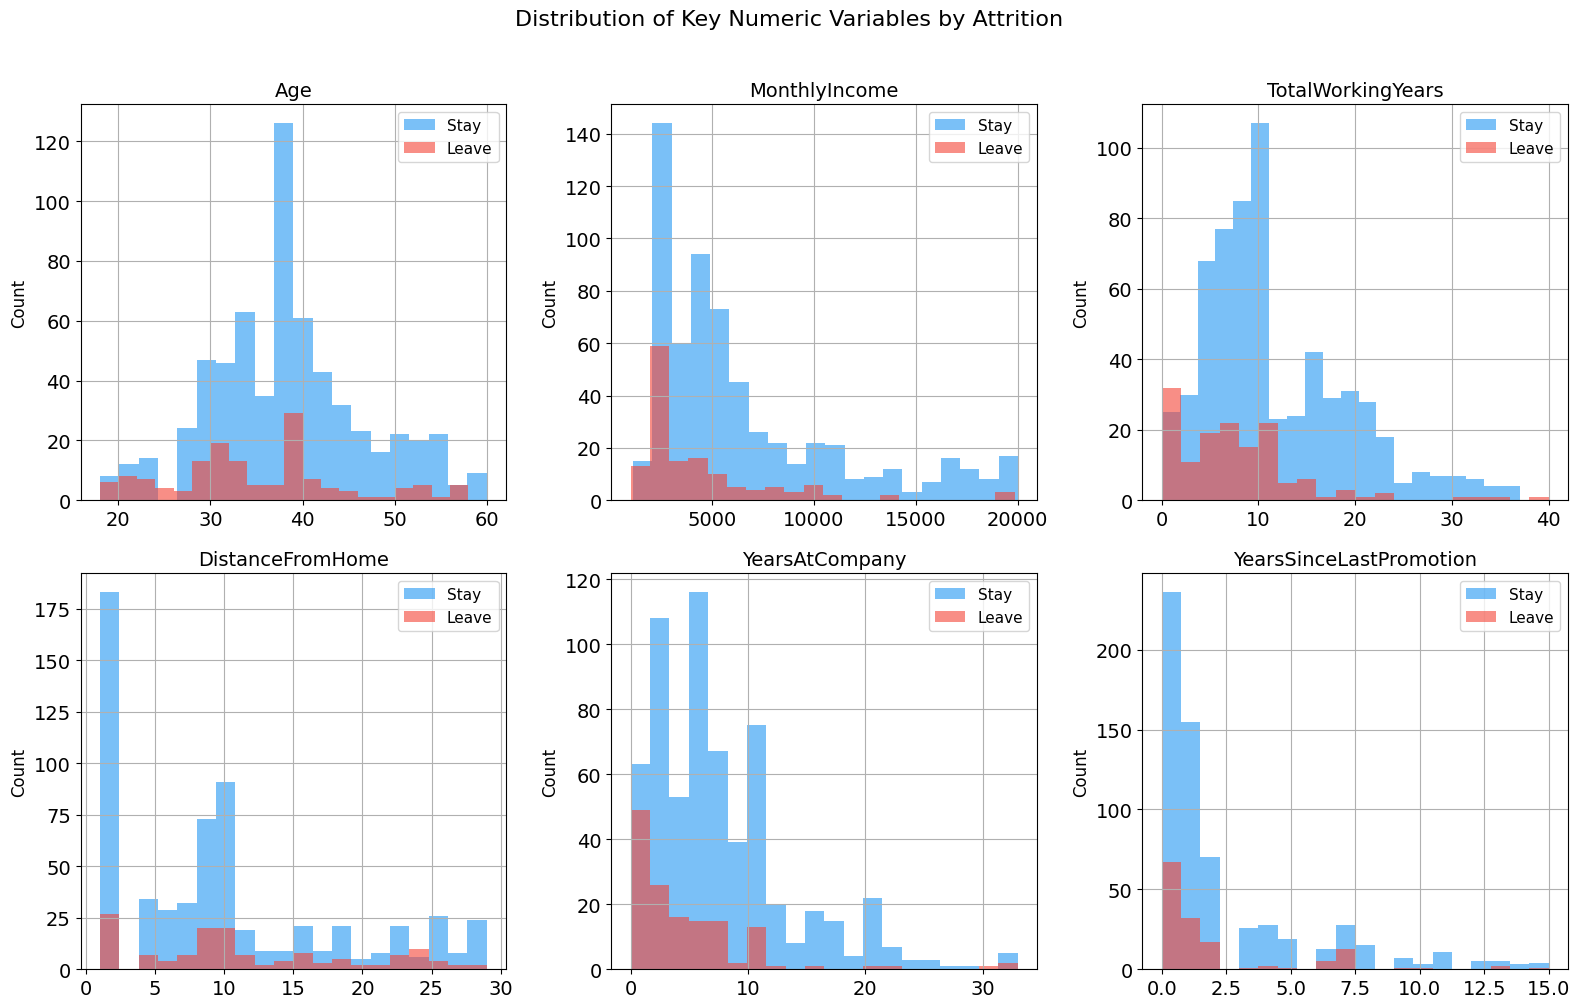

In [6]:
# Numeric variables: distribution by attrition
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_vars = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
            'DistanceFromHome', 'YearsAtCompany', 'YearsSinceLastPromotion']

for ax, var in zip(axes.flatten(), num_vars):
    df[df['Attrition'] == 'No'][var].hist(ax=ax, alpha=0.6, bins=20, color='#2196F3', label='Stay')
    df[df['Attrition'] == 'Yes'][var].hist(ax=ax, alpha=0.6, bins=20, color='#F44336', label='Leave')
    ax.set_title(var, fontsize=14)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(fontsize=11)

plt.suptitle('Distribution of Key Numeric Variables by Attrition', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 2. Feature Engineering & Data Preparation

In [7]:
# Columns to drop: constants, IDs, or redundant
DROP_COLS = ['SequenceNumber', 'EmployeeCount', 'EmployeeNumber',
             'Over18', 'StandardHours']

def prepare_features(data, drop_cols=DROP_COLS, fit_dummies=None):
    """Prepare features: drop constants, encode categoricals."""
    d = data.drop(columns=[c for c in drop_cols if c in data.columns], errors='ignore')
    # Encode binary target if present
    if 'Attrition' in d.columns:
        d['Attrition'] = (d['Attrition'] == 'Yes').astype(int)
    # One-hot encode categorical variables
    cat_cols = d.select_dtypes(include='object').columns.tolist()
    if 'Attrition' in cat_cols:
        cat_cols.remove('Attrition')
    d = pd.get_dummies(d, columns=cat_cols, drop_first=True)
    return d

train_df = prepare_features(df)
print(f'Training features shape: {train_df.shape}')
train_df.head(2)

Training features shape: (771, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,59.0000,0,818.0000,6.0000,2,2,52,3,1,3,2267,25657,8,17,3,4,0,7,2,2,2,2,2,2,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,True,False,False
1,56.0000,0,832.0000,9.0000,3,3,81,3,4,4,11103,20420,7,11,3,3,0,30,1,2,10,7,1,1,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False


In [8]:
# Prepare Lyon data with the same feature columns
lyon_df = prepare_features(lyon)

# Align Lyon columns to training columns (excluding target)
feature_cols = [c for c in train_df.columns if c != 'Attrition']
lyon_df = lyon_df.reindex(columns=feature_cols, fill_value=0)

print(f'Lyon features shape:     {lyon_df.shape}')
print(f'Training feature cols:   {len(feature_cols)}')

Lyon features shape:     (258, 44)
Training feature cols:   44


## 3. Logistic Regression Model

In [9]:
X = train_df[feature_cols]
y = train_df['Attrition']

# Train-validation split (80/20, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_lyon_sc  = scaler.transform(lyon_df)

print(f'Train size: {X_train.shape[0]}  |  Validation size: {X_val.shape[0]}')

Train size: 616  |  Validation size: 155


In [10]:
# Fit logistic regression (with class_weight='balanced' for imbalanced target)
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_sc, y_train)

val_probs = model.predict_proba(X_val_sc)[:, 1]
val_preds = model.predict(X_val_sc)

print('Validation Classification Report:')
print(classification_report(y_val, val_preds, target_names=['Stay', 'Leave']))
print(f'Validation AUC-ROC: {roc_auc_score(y_val, val_probs):.4f}')

Validation Classification Report:
              precision    recall  f1-score   support

        Stay       0.91      0.82      0.86       126
       Leave       0.45      0.66      0.54        29

    accuracy                           0.79       155
   macro avg       0.68      0.74      0.70       155
weighted avg       0.83      0.79      0.80       155

Validation AUC-ROC: 0.7956


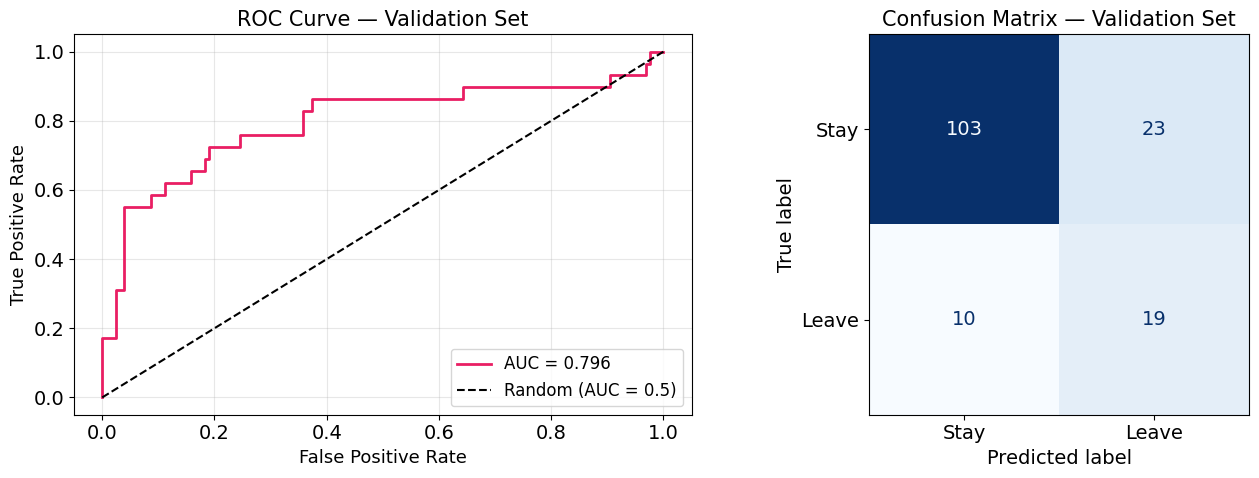

In [11]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_probs)
auc_score = roc_auc_score(y_val, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#E91E63', lw=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title('ROC Curve — Validation Set', fontsize=15)
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Leave'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Validation Set', fontsize=15)

plt.tight_layout()
plt.show()

## 4. Feature Importance — Odds Ratios

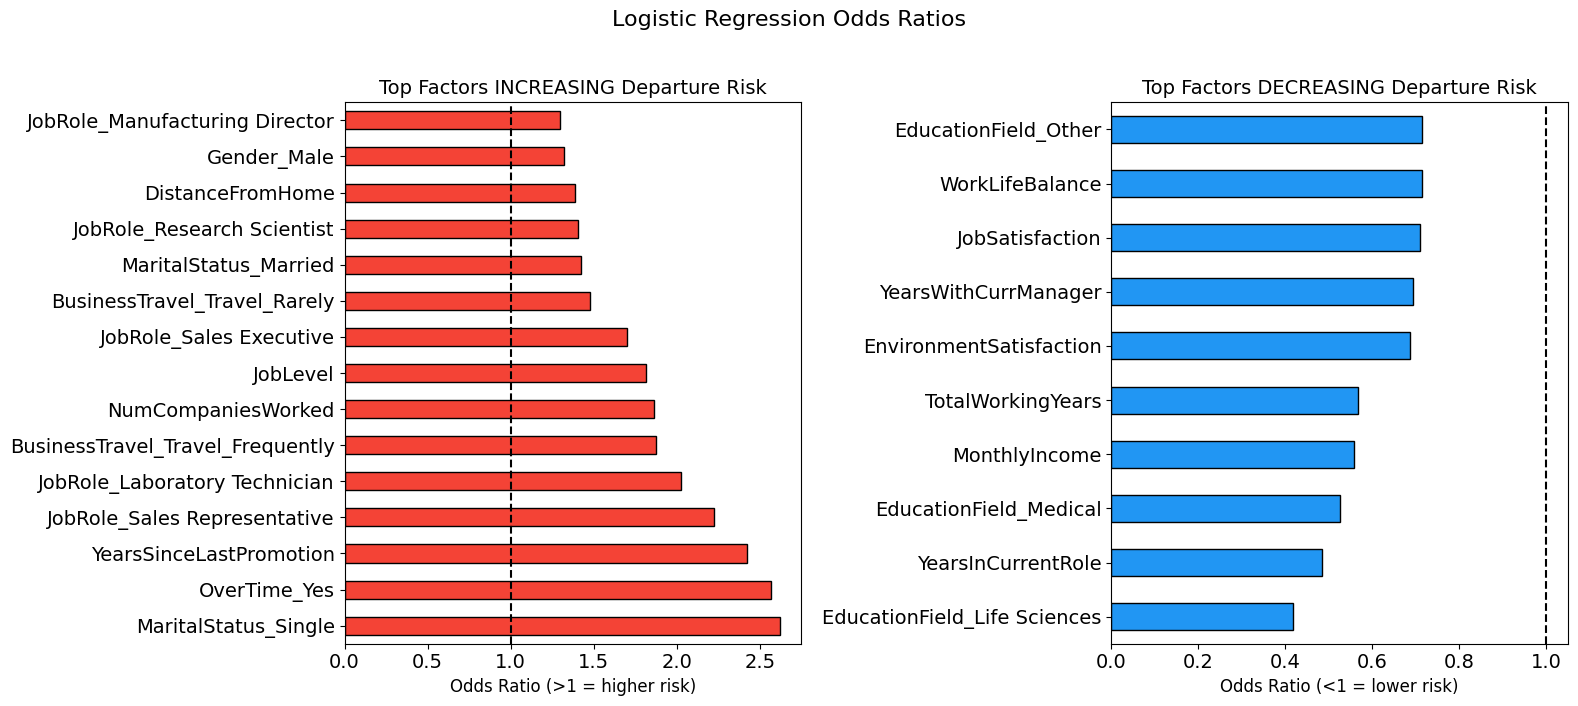


Top 10 factors increasing departure probability:
                                  Odds Ratio
MaritalStatus_Single                  2.6186
OverTime_Yes                          2.5682
YearsSinceLastPromotion               2.4208
JobRole_Sales Representative          2.2265
JobRole_Laboratory Technician         2.0277
BusinessTravel_Travel_Frequently      1.8748
NumCompaniesWorked                    1.8657
JobLevel                              1.8165
JobRole_Sales Executive               1.7016
BusinessTravel_Travel_Rarely          1.4767

Top 10 factors decreasing departure probability:
                              Odds Ratio
EducationField_Life Sciences      0.4183
YearsInCurrentRole                0.4852
EducationField_Medical            0.5266
MonthlyIncome                     0.5583
TotalWorkingYears                 0.5665
EnvironmentSatisfaction           0.6858
YearsWithCurrManager              0.6943
JobSatisfaction                   0.7105
WorkLifeBalance                   0.

In [12]:
# Compute odds ratios from logistic regression coefficients
odds_ratios = pd.Series(
    np.exp(model.coef_[0]),
    index=feature_cols
).sort_values(ascending=False)

# Top 15 factors increasing and decreasing attrition
top_increase = odds_ratios[odds_ratios > 1].head(15)
top_decrease = odds_ratios[odds_ratios < 1].tail(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_increase.plot(kind='barh', ax=axes[0], color='#F44336', edgecolor='black')
axes[0].axvline(1, color='black', lw=1.5, linestyle='--')
axes[0].set_title('Top Factors INCREASING Departure Risk', fontsize=14)
axes[0].set_xlabel('Odds Ratio (>1 = higher risk)', fontsize=12)

top_decrease.plot(kind='barh', ax=axes[1], color='#2196F3', edgecolor='black')
axes[1].axvline(1, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Top Factors DECREASING Departure Risk', fontsize=14)
axes[1].set_xlabel('Odds Ratio (<1 = lower risk)', fontsize=12)

plt.suptitle('Logistic Regression Odds Ratios', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print('\nTop 10 factors increasing departure probability:')
print(top_increase.head(10).to_frame('Odds Ratio'))
print('\nTop 10 factors decreasing departure probability:')
print(top_decrease.head(10).to_frame('Odds Ratio'))

## 5. Lyon Employee Predictions

In [13]:
# Generate departure probabilities for Lyon employees
lyon_probs = model.predict_proba(X_lyon_sc)[:, 1]

# Attach predictions to original Lyon dataframe
results = lyon.copy()
results['predictions'] = lyon_probs

print(f'Lyon employees: {len(results)}')
print(f'\nPredicted departure probability statistics:')
print(results['predictions'].describe())
print(f'\nExpected # departures (sum of probabilities): {lyon_probs.sum():.1f}')

Lyon employees: 258

Predicted departure probability statistics:
count   258.0000
mean      0.2843
std       0.2909
min       0.0001
25%       0.0383
50%       0.1650
75%       0.4738
max       0.9874
Name: predictions, dtype: float64

Expected # departures (sum of probabilities): 73.4


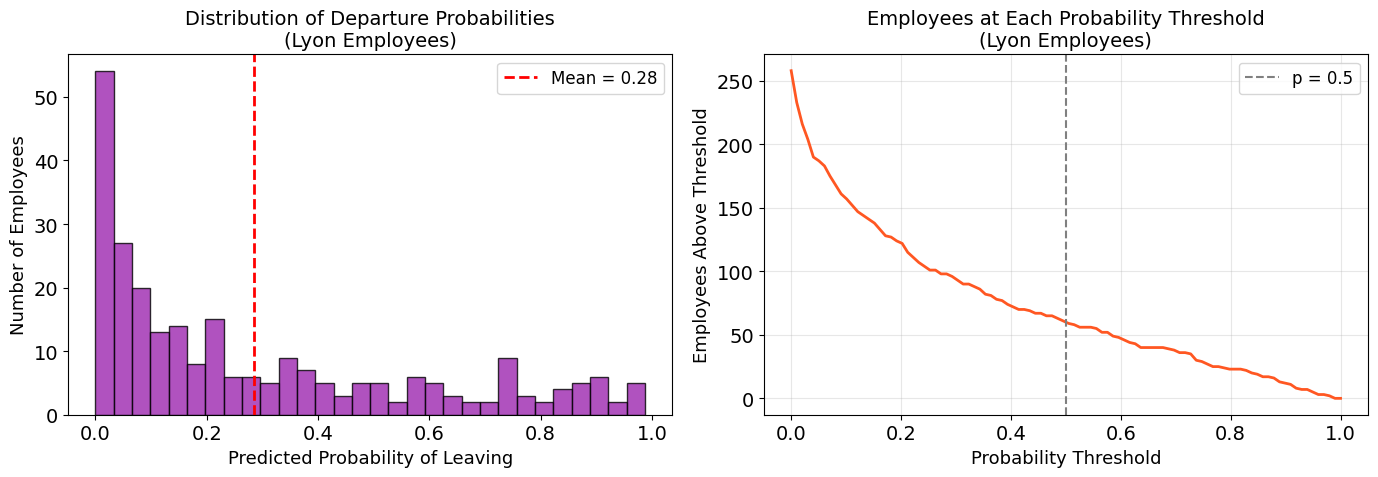

In [14]:
# Distribution of predicted departure probabilities for Lyon employees
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(lyon_probs, bins=30, color='#9C27B0', edgecolor='black', alpha=0.8)
axes[0].axvline(lyon_probs.mean(), color='red', lw=2, linestyle='--',
                label=f'Mean = {lyon_probs.mean():.2f}')
axes[0].set_xlabel('Predicted Probability of Leaving', fontsize=13)
axes[0].set_ylabel('Number of Employees', fontsize=13)
axes[0].set_title('Distribution of Departure Probabilities\n(Lyon Employees)', fontsize=14)
axes[0].legend(fontsize=12)

# Cumulative: how many expected to leave at each probability threshold
thresholds = np.linspace(0, 1, 100)
expected_leavers = [(lyon_probs >= t).sum() for t in thresholds]
axes[1].plot(thresholds, expected_leavers, color='#FF5722', lw=2)
axes[1].axvline(0.5, color='gray', lw=1.5, linestyle='--', label='p = 0.5')
axes[1].set_xlabel('Probability Threshold', fontsize=13)
axes[1].set_ylabel('Employees Above Threshold', fontsize=13)
axes[1].set_title('Employees at Each Probability Threshold\n(Lyon Employees)', fontsize=14)
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Lyon Employee Risk Segmentation:
                      Count    Pct
risk_segment                      
High (≥70%)              38  14.7%
Medium-High (50–70%)     22   8.5%
Medium-Low (30–50%)      33  12.8%
Low (<30%)              165  64.0%


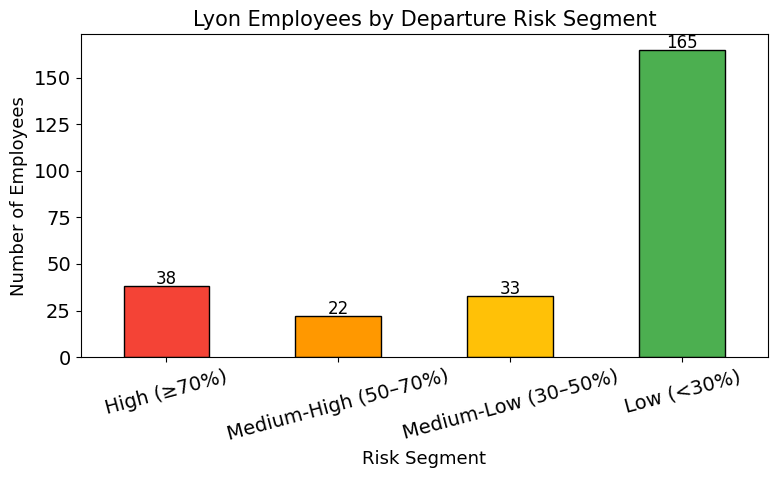

In [15]:
# Risk segmentation of Lyon employees
def risk_segment(p):
    if p >= 0.7:   return 'High (≥70%)'
    elif p >= 0.5: return 'Medium-High (50–70%)'
    elif p >= 0.3: return 'Medium-Low (30–50%)'
    else:          return 'Low (<30%)'

results['risk_segment'] = results['predictions'].apply(risk_segment)
segment_order = ['High (≥70%)', 'Medium-High (50–70%)', 'Medium-Low (30–50%)', 'Low (<30%)']
segment_counts = results['risk_segment'].value_counts().reindex(segment_order)

print('Lyon Employee Risk Segmentation:')
print(segment_counts.to_frame('Count').assign(
    Pct=lambda d: (d['Count']/len(results)*100).round(1).astype(str)+'%'
))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#F44336', '#FF9800', '#FFC107', '#4CAF50']
segment_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Lyon Employees by Departure Risk Segment', fontsize=15)
ax.set_xlabel('Risk Segment', fontsize=13)
ax.set_ylabel('Number of Employees', fontsize=13)
ax.tick_params(axis='x', rotation=15)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# Top 20 Lyon employees most likely to leave
top_leavers = results.nlargest(20, 'predictions')[[
    'SequenceNumber', 'Age', 'Department', 'JobRole',
    'MonthlyIncome', 'YearsAtCompany', 'OverTime', 'MaritalStatus', 'predictions'
]]
print('Top 20 Lyon employees most likely to accept RCC:')
top_leavers.round(4)

Top 20 Lyon employees most likely to accept RCC:


,SequenceNumber,Age,Department,JobRole,MonthlyIncome,YearsAtCompany,OverTime,MaritalStatus,predictions
247,247,33.0000,Research & Development,Research Scientist,2313,2,Yes,Single,0.9874
163,163,32.0000,Sales,Sales Executive,9907,2,Yes,Single,0.9841
183,183,48.0000,Research & Development,Laboratory Technician,5381,1,Yes,Single,0.9762
77,77,19.0000,Sales,Sales Representative,2325,0,No,Single,0.9574
43,43,34.0000,Sales,Sales Executive,5304,5,Yes,Single,0.9571
243,243,29.0000,Research & Development,Laboratory Technician,2319,1,Yes,Single,0.9447
22,22,60.0000,Sales,Sales Executive,5405,2,No,Single,0.9394
32,32,38.0000,Sales,Sales Executive,4614,4,Yes,Married,0.9195
226,226,41.0000,Sales,Sales Executive,5993,6,Yes,Single,0.9192
107,107,27.0000,Research & Development,Manufacturing Director,4298,2,No,Married,0.9172


## 6. Model Validation on Full Training Set

In [17]:
# Retrain on full training set for final predictions
X_all_sc = scaler.fit_transform(X)
X_lyon_sc_final = scaler.transform(lyon_df)

model_final = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_final.fit(X_all_sc, y)

lyon_probs_final = model_final.predict_proba(X_lyon_sc_final)[:, 1]
results['predictions'] = lyon_probs_final

print(f'Final model trained on all {len(X)} training examples')
print(f'Lyon predictions — mean: {lyon_probs_final.mean():.3f}, '
      f'min: {lyon_probs_final.min():.3f}, max: {lyon_probs_final.max():.3f}')

Final model trained on all 771 training examples
Lyon predictions — mean: 0.313, min: 0.001, max: 0.973


## 7. Export Predictions

In [18]:
# Export in the same format as example_predictions.csv
export_cols = [c for c in lyon.columns] + ['predictions']
results[export_cols].to_csv('lyon_departure_predictions.csv', index=False)
print('Saved: lyon_departure_predictions.csv')
print(f'\nFirst 5 rows:')
results[export_cols].head()

Saved: lyon_departure_predictions.csv

First 5 rows:


,SequenceNumber,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,predictions
0,0,38.0000,Travel_Rarely,920.0000,Human Resources,20.0000,2,Medical,1,1818,4,Female,69,3,1,Human Resources,2,Married,2148,6889,0,Y,Yes,11,3,3,80,0,6,3,3,5,1,1,4,0.2064
1,1,44.0000,Travel_Frequently,383.0000,Sales,1.0000,5,Marketing,1,1481,1,Female,79,3,2,Sales Executive,3,Married,4768,9282,7,Y,No,12,3,3,80,1,11,4,2,1,0,0,0,0.6134
2,2,48.0000,Non-Travel,1262.0000,Research & Development,1.0000,4,Medical,1,1116,1,Male,35,4,4,Manager,4,Single,16885,16154,2,Y,No,22,4,3,80,0,27,3,2,5,4,2,1,0.0052
3,3,54.0000,Travel_Rarely,1217.0000,Research & Development,2.0000,4,Technical Degree,1,126,1,Female,60,3,3,Research Director,3,Married,13549,24001,9,Y,No,12,3,1,80,1,16,5,1,4,3,0,3,0.2660
4,4,32.0000,Travel_Rarely,334.0000,Research & Development,10.0000,2,Life Sciences,1,21,1,Male,80,4,1,Research Scientist,2,Divorced,3298,15053,0,Y,Yes,12,3,4,80,2,7,5,2,6,2,0,5,0.1707


## 8. Policy Recommendations — How SFB Should Use These Probabilities

### Targeting Strategy

SFB's goal with the RCC is to **reduce headcount at Lyon by a target number** at minimum cost, while preserving critical talent. The predicted departure probabilities enable a **tiered targeting approach**:

| Segment | Action |
|---|---|
| **High risk (p ≥ 0.70)**: likely to accept anyway | Offer standard RCC package — low incentive needed |
| **Medium-High (0.50–0.70)**: persuadable | Offer enhanced RCC package to nudge acceptance |
| **Medium-Low (0.30–0.50)**: uncertain | Consider targeted negotiation for key roles only |
| **Low risk (p < 0.30)**: likely to stay | Do NOT offer RCC proactively — risk of undesired loss |

### Key Risks

1. **False negatives (missed leavers):** Employees predicted as low-risk but who would have accepted are not offered the RCC, leaving headcount above target.

2. **False positives (unwanted departures):** Offering RCC to employees predicted as high-risk who are also high-performers triggers unplanned talent loss. Cross-check predictions with performance ratings.

3. **Adverse selection:** If only high-probability employees accept the RCC, SFB loses its most "disengaged" workforce but may not reach its headcount target. Need to model the gap between predicted acceptances and target.

4. **Legal/regulatory risk (France):** French RCC law requires collective agreement and cannot discriminate in who is offered the package. Predictions should inform financial modeling, not restrict access to the RCC.

5. **Model reliability:** The model was trained on past RCC data that may not represent Lyon's workforce composition. Model should be validated against known Lyon attrition patterns.

6. **Calibration uncertainty:** Predicted probabilities are relative, not absolute. SFB should use probabilities for **ranking** rather than as literal acceptance rates.

In [19]:
# Expected headcount reduction at different probability thresholds
print('Expected RCC acceptances at each threshold (based on probability sums):')
print('-' * 50)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    above = (lyon_probs_final >= t).sum()
    expected = lyon_probs_final[lyon_probs_final >= t].sum()
    print(f'Threshold {t:.1f}: {above:3d} employees above threshold, '
          f'~{expected:.0f} expected acceptances')

Expected RCC acceptances at each threshold (based on probability sums):
--------------------------------------------------
Threshold 0.3: 108 employees above threshold, ~65 expected acceptances
Threshold 0.4:  83 employees above threshold, ~56 expected acceptances
Threshold 0.5:  69 employees above threshold, ~50 expected acceptances
Threshold 0.6:  51 employees above threshold, ~40 expected acceptances
Threshold 0.7:  39 employees above threshold, ~32 expected acceptances


---
*Analysis restricted to logistic regression as covered in class.*